In [2]:
# These are the tools for this notebook
# datasets  → talks to HuggingFace to download MedHallu
# pandas    → lets us filter/count/group the data like a spreadsheet
# matplotlib/seaborn → draw charts

from datasets import load_dataset
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

c:\Users\GHANSHYAM\Desktop\medhallu-detector\medhallu-detector\myenv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
# pqa_artificial = 10,000 rows with hallucinated answers (this is what we need)
# pqa_labeled    = smaller human-labeled subset (not what we want)

ds = load_dataset("UTAustin-AIHealth/MedHallu", "pqa_artificial")
print(ds)
print(ds["train"].column_names)

Generating train split: 100%|██████████| 9000/9000 [00:00<00:00, 25996.30 examples/s]

DatasetDict({
    train: Dataset({
        features: ['Question', 'Knowledge', 'Ground Truth', 'Difficulty Level', 'Hallucinated Answer', 'Category of Hallucination'],
        num_rows: 9000
    })
})
['Question', 'Knowledge', 'Ground Truth', 'Difficulty Level', 'Hallucinated Answer', 'Category of Hallucination']


In [20]:
df = ds["train"].to_pandas()
df.sample(10)

,Question,Knowledge,Ground Truth,Difficulty Level,Hallucinated Answer,Category of Hallucination
4742,Do stem cells improve the quality of colonic a...,[Stem cells have multiple ways of differentiat...,These findings suggest a novel role for mesenc...,hard,Stem cells improve colonic anastomosis quality...,Misinterpretation of #Question#
6492,Does vasoactive intestinal peptide inhibit adh...,[Stricture formation in Crohn's disease (CD) o...,VIP has an inhibitory effect on IL-1beta-induc...,hard,Vasoactive intestinal peptide (VIP) inhibits a...,Misinterpretation of #Question#
4600,Are functional polymorphisms of UCP2 and UCP3 ...,[We studied the association between polymorphi...,Our data indicate that both the G-866A polymor...,medium,Our data indicate that the G-866A polymorphism...,Incomplete Information
7771,Do volatile organic compounds enhance allergic...,[Epidemiological studies suggest an associatio...,Our results demonstrate that exposure to VOCs ...,hard,Recent studies indicate that exposure to volat...,Misinterpretation of #Question#
7185,Is the expression of disabled-2 common reduced...,[Disabled-2 (Dab2) is frequently down-regulate...,Dab2 is expressed at variable level in meningi...,medium,Dab2 expression is universally reduced in all ...,Misinterpretation of #Question#
8940,Do adverse childhood experiences influence dev...,[To investigate the association between advers...,Adverse childhood experiences were associated ...,easy,Adverse childhood experiences were significant...,Misinterpretation of #Question#
4964,Do high Plasma Concentrations of Zidovudine ( ...,[Zidovudine (AZT) is mainly used to prevent mo...,"The level of icAZT-TP did not change with age,...",easy,High plasma concentrations of Zidovudine (AZT)...,Misinterpretation of #Question#
8843,Are not all gleason pattern 4 prostate cancers...,[The Gleason grading system represents the cor...,Our study revealed that in latent prostate can...,easy,Our study found that all Gleason pattern 4 pro...,Misinterpretation of #Question#
5148,Do heat shock protein complex vaccines induce ...,[Neisseria meningitidis are common colonizers ...,N. lactamica and N. meningitidis HSPC vaccines...,medium,Heat shock protein complex vaccines against Ne...,Misinterpretation of #Question#
172,Does sexual activity predispose to reflux epis...,[The role of sexual activity on gastroesophage...,Sexual activity does not predispose to increas...,hard,Sexual activity significantly increases the ri...,Misinterpretation of #Question#


In [6]:
# Check what splits are actually available
print(ds)
print("\nAvailable splits:", list(ds.keys()))

DatasetDict({
    train: Dataset({
        features: ['Question', 'Knowledge', 'Ground Truth', 'Difficulty Level', 'Hallucinated Answer', 'Category of Hallucination'],
        num_rows: 9000
    })
})

Available splits: ['train']


In [7]:
# Only 'train' split exists with 9000 rows
# Column names are different from what we expected — noted below:
#
# 'Question'                  → the medical question
# 'Knowledge'                 → the source / ground truth context
# 'Ground Truth'              → the correct answer
# 'Hallucinated Answer'       → the wrong answer the LLM gave
# 'Difficulty Level'          → easy / medium / hard
# 'Category of Hallucination' → misinterpretation / fabrication / etc.
#
# WHY no 'label' column:
# Every row in pqa_artificial IS hallucinated by definition
# The label is always "hallucinated" — we add it manually

full_df = ds["train"].to_pandas()

# Add the label column — all rows are hallucinated
full_df["label"] = "hallucinated"

# Rename columns to match our code throughout the project
# WHY rename: all our training code uses lowercase snake_case names
# Renaming here means we don't have to change every other file
full_df = full_df.rename(columns={
    "Question":                  "question",
    "Knowledge":                 "source",
    "Ground Truth":              "ground_truth",
    "Hallucinated Answer":       "answer",
    "Difficulty Level":          "difficulty",
    "Category of Hallucination": "hallucination_type",
})

print(f"Total rows : {len(full_df)}")
print(f"Columns    : {full_df.columns.tolist()}")

# Split into train / val / test
# 7000 train | 1000 validation | 1000 test
train_df = full_df.iloc[:7000].reset_index(drop=True)
val_df   = full_df.iloc[7000:8000].reset_index(drop=True)
test_df  = full_df.iloc[8000:].reset_index(drop=True)

print(f"\nTrain rows : {len(train_df)}")
print(f"Val rows   : {len(val_df)}")
print(f"Test rows  : {len(test_df)}")

print("\n--- First row ---")
print(train_df.iloc[0].to_dict())

Total rows : 9000
Columns    : ['question', 'source', 'ground_truth', 'difficulty', 'answer', 'hallucination_type', 'label']

Train rows : 7000
Val rows   : 1000
Test rows  : 1000

--- First row ---
{'question': 'Are group 2 innate lymphoid cells ( ILC2s ) increased in chronic rhinosinusitis with nasal polyps or eosinophilia?', 'source': array(['Chronic rhinosinusitis (CRS) is a heterogeneous disease with an uncertain pathogenesis. Group 2 innate lymphoid cells (ILC2s) represent a recently discovered cell population which has been implicated in driving Th2 inflammation in CRS; however, their relationship with clinical disease characteristics has yet to be investigated.',
       'The aim of this study was to identify ILC2s in sinus mucosa in patients with CRS and controls and compare ILC2s across characteristics of disease.',
       'A cross-sectional study of patients with CRS undergoing endoscopic sinus surgery was conducted. Sinus mucosal biopsies were obtained during surgery and con

In [8]:
# "label" tells us if the LLM answer is hallucinated or grounded
# We need to know if the classes are balanced — imbalance affects F1

print("=== Label counts ===")
print(train_df["label"].value_counts())
print("\n=== As percentages ===")
print(train_df["label"].value_counts(normalize=True).round(3))

=== Label counts ===
label
hallucinated    7000
Name: count, dtype: int64

=== As percentages ===
label
hallucinated    1.0
Name: proportion, dtype: float64


In [9]:
# MedHallu has 3 difficulty tiers: easy, medium, hard
# Hard rows are semantically closer to ground truth — harder to detect
# This matters when we report F1 per-difficulty in the results table

print("=== Difficulty counts ===")
print(train_df["difficulty"].value_counts())

=== Difficulty counts ===
difficulty
hard      2471
easy      2305
medium    2224
Name: count, dtype: int64


In [10]:
# Types: misinterpretation, fabrication, contradiction, omission
# Person 2's second head will predict this — so we need to know the balance

print("=== Hallucination type counts ===")
print(train_df["hallucination_type"].value_counts())
print("\nNull/missing values:", train_df["hallucination_type"].isna().sum())

=== Hallucination type counts ===
hallucination_type
Misinterpretation of #Question#            5313
Mechanism and Pathway Misattribution        841
Incomplete Information                      811
Methodological and Evidence Fabrication      35
Name: count, dtype: int64

Null/missing values: 0


In [11]:
# Why does length matter?
# DeBERTa has a 512 token limit — long answers get truncated
# We need to know how many rows will be affected

train_df["answer_len"] = train_df["answer"].str.split().str.len()
train_df["source_len"] = train_df["source"].str.split().str.len()

print("=== Answer word count ===")
print(train_df["answer_len"].describe().round(1))

print("\n=== Source word count ===")
print(train_df["source_len"].describe().round(1))

# How many rows are over 400 words combined (risky for 512 token limit)?
combined = train_df["answer_len"] + train_df["source_len"]
print(f"\nRows over 400 combined words: {(combined > 400).sum()} / {len(train_df)}")

=== Answer word count ===
count    7000.0
mean       27.7
std        16.9
min         1.0
25%        18.0
50%        22.0
75%        30.0
max       192.0
Name: answer_len, dtype: float64

=== Source word count ===
count       0
unique      0
top       NaN
freq      NaN
Name: source_len, dtype: object

Rows over 400 combined words: 0 / 7000


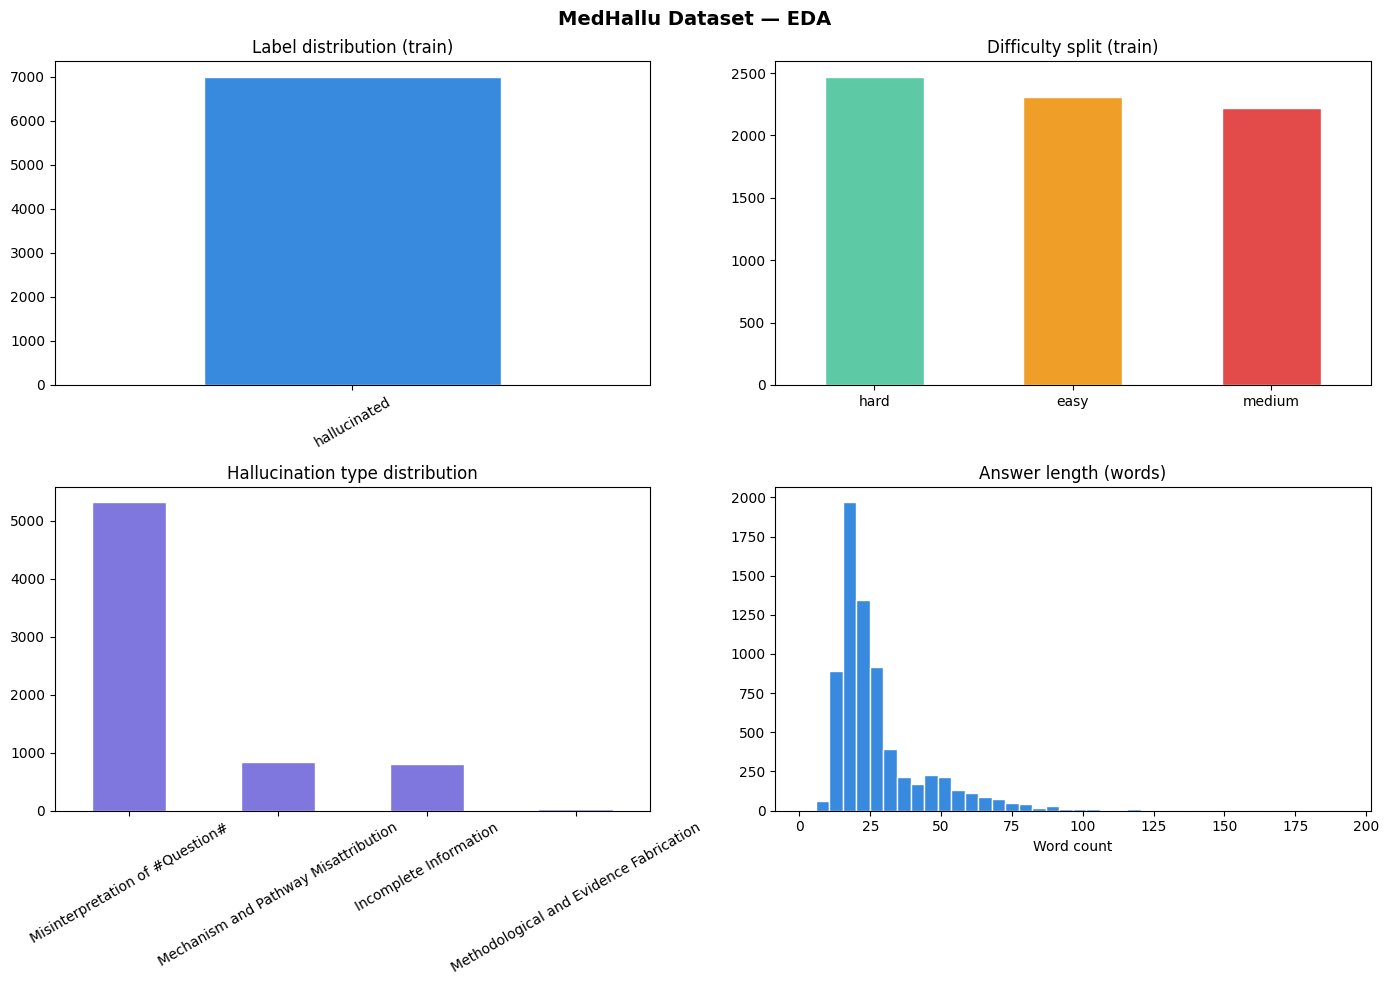

Saved to outputs/eda_charts.png


In [12]:
# This produces the EDA charts for your project report
# Save to outputs/ so Person 3 can use them in the Gradio dashboard tab

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("MedHallu Dataset — EDA", fontsize=14, fontweight="bold")

# Chart 1: label distribution
train_df["label"].value_counts().plot(
    kind="bar", ax=axes[0][0], color=["#378ADD", "#E24B4A", "#EF9F27", "#1D9E75"],
    edgecolor="white"
)
axes[0][0].set_title("Label distribution (train)")
axes[0][0].set_xlabel("")
axes[0][0].tick_params(axis="x", rotation=30)

# Chart 2: difficulty split
train_df["difficulty"].value_counts().plot(
    kind="bar", ax=axes[0][1], color=["#5DCAA5", "#EF9F27", "#E24B4A"],
    edgecolor="white"
)
axes[0][1].set_title("Difficulty split (train)")
axes[0][1].set_xlabel("")
axes[0][1].tick_params(axis="x", rotation=0)

# Chart 3: hallucination type
train_df["hallucination_type"].value_counts().plot(
    kind="bar", ax=axes[1][0], color="#7F77DD", edgecolor="white"
)
axes[1][0].set_title("Hallucination type distribution")
axes[1][0].set_xlabel("")
axes[1][0].tick_params(axis="x", rotation=30)

# Chart 4: answer length histogram
axes[1][1].hist(train_df["answer_len"], bins=40, color="#378ADD", edgecolor="white")
axes[1][1].set_title("Answer length (words)")
axes[1][1].set_xlabel("Word count")

plt.tight_layout()
plt.savefig("outputs/eda_charts.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved to outputs/eda_charts.png")

In [13]:
# This is the most important cell — read every printed example carefully
# You are building intuition for what "fabrication" vs "misinterpretation" looks like
# This cannot be replaced by any metric

for htype in train_df["hallucination_type"].dropna().unique():
    subset = train_df[train_df["hallucination_type"] == htype].head(5)
    print(f"\n{'='*60}")
    print(f"TYPE: {htype.upper()}")
    print(f"{'='*60}")
    for _, row in subset.iterrows():
        print(f"\nQ:      {row['question'][:200]}")
        print(f"ANSWER: {row['answer'][:200]}")
        print(f"LABEL:  {row['label']}  |  DIFFICULTY: {row['difficulty']}")
        print("-" * 40)


TYPE: MISINTERPRETATION OF #QUESTION#

Q:      Are group 2 innate lymphoid cells ( ILC2s ) increased in chronic rhinosinusitis with nasal polyps or eosinophilia?
ANSWER: Group 2 innate lymphoid cells (ILC2s) are significantly decreased in chronic rhinosinusitis with nasal polyps and eosinophilia. Studies have shown that a reduction in ILC2s correlates with increased e
LABEL:  hallucinated  |  DIFFICULTY: easy
----------------------------------------

Q:      Does vagus nerve contribute to the development of steatohepatitis and obesity in phosphatidylethanolamine N-methyltransferase deficient mice?
ANSWER: Capsaicin-induced disruption of hepatic afferent vagus nerve significantly increases the development of steatohepatitis in Pemt(-/-) mice.
LABEL:  hallucinated  |  DIFFICULTY: medium
----------------------------------------

Q:      Does psammaplin A induce Sirtuin 1-dependent autophagic cell death in doxorubicin-resistant MCF-7/adr human breast cancer cells and xenografts?
ANSWER: P

label       hallucinated
difficulty              
easy                 1.0
hard                 1.0
medium               1.0


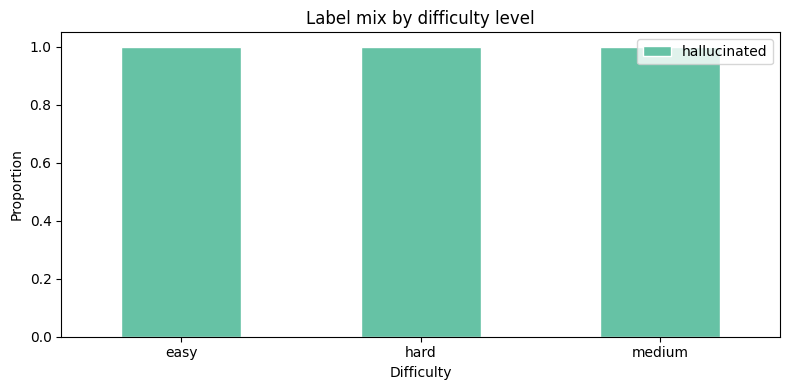

In [14]:
# Do hard rows have more hallucinations? Are easy rows mostly grounded?
# This cross-tab answers that and should go in your report

ct = pd.crosstab(train_df["difficulty"], train_df["label"], normalize="index").round(3)
print(ct)

# Visualise it
ct.plot(kind="bar", figsize=(8, 4), colormap="Set2", edgecolor="white")
plt.title("Label mix by difficulty level")
plt.xlabel("Difficulty")
plt.ylabel("Proportion")
plt.xticks(rotation=0)
plt.legend(loc="upper right")
plt.tight_layout()
plt.savefig("outputs/difficulty_label_crosstab.png", dpi=150)
plt.show()